### Imports

In [97]:
import numpy as np
import pandas as pd
import sklearn as skl
import skimage as ski
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt

### Constant, Variable, and DataFrame Instatiation

In [ ]:
PALLET_DIMS = (1000, 1400, 1400)                                                # Length, width, height (X, Y, Z, respectively) in mm
DEFAULT_MAX_ATTEMPTS = 2000                                                     # Default cutoff for random attempts to place boxes
DEFAULT_CRITERION = "v"                                                         # Default criterion for box sorting
ML_OBSERVATION_SCALE_FACTOR = 10                                                # Scale factor to scale down height map observations for ML model input
SUPPORTED_AREA_PERCENTAGE = 70                                                  # Percentage of pallet area that must be supported under a box for it to be placed

boxtypes = pd.read_csv("boxtypes.csv")                                          # Load box type dimensions
orders = pd.read_csv("orders.csv")                                              # Load orders data

#### Environment Definition

In [ ]:
class Pallet:
    # Basic functionality methods
    def __init__(self, dims=PALLET_DIMS):                                       # Initialize pallet with given dimensions
        # unpack pallet dimensions
        self.size_x, self.size_y, self.size_z = dims
        # Initialize list to store boxes placed on the pallet
        self.boxes = []
        # Initialize heightmap to track box heights at each (x, y) position
        self.heightmap = np.zeros((self.size_x, self.size_y), dtype=np.int32)

    def reset(self):                                                            # Emtpy the pallet
        # Clear the list of boxes
        self.boxes = []
        # Reset the heightmap to all zeros
        self.heightmap = np.zeros((self.size_x, self.size_y))

    # Box placement logic
    def get_in_bounds_status(self, x, y, z):                                    # Check if the given (x, y, z) position is within the pallet boundaries
        return (x <= self.size_x) and (y <= self.size_y) and (z <= self.size_z)
    
    def get_in_box_status(self, x, y, z):                                       # Check if the given (x, y, z) position is inside any box on the pallet
        for box in self.boxes:
            if (box['x'] <= x < box['x'] + box['dx'] and
                box['y'] <= y < box['y'] + box['dy'] and
                box['z'] <= z < box['z'] + box['dz']):
                return True
        return False

    def place_box(self, box_dims, x, y):                                        # Attempt to place a box of given dimensions at (x, y) position on the pallet
        # Unpack box dimensions
        dx, dy, dz = box_dims

        # Make sure x and y are ints so we don't get partial millimeters from the model
        x = int(x)
        y = int(y)

        # Get the height the bottom of the box will be
        z = self.get_max_height_in_area(x, y, dx, dy)

        # Check if there is enough support under the box, or return False
        box_area = dx * dy
        area_supported = np.sum(self.heightmap[x:x+dx, y:y+dy] == z)
        support_percentage = (area_supported / box_area) * 100
        if support_percentage < SUPPORTED_AREA_PERCENTAGE:
            return False

        # Check if the box fits within the pallet boundaries, or return False
        if not self.get_in_bounds_status(x+dx, y+dy, z+dz):
            return False

        # Place the box by updating the heightmap
        self.heightmap[x:x+dx, y:y+dy] = z + dz

        # Store the box's position and dimensions
        self.boxes.append({
            'x': x, 'y': y, 'z': z, 'dx': dx, 'dy': dy, 'dz': dz
        })

        # Return True to indicate successful placement
        return True

    # Pallet state and analysis methods    
    def get_max_height_in_area(self, x, y, dx, dy):                             # Get the maximum height in a rectangular area of the heightmap
        # Ensure we don't go out of bounds
        x_end = min(x + dx, self.size_x)                                          
        y_end = min(y + dy, self.size_y)

        # Specify the rectangle being checked
        region = self.heightmap[x:x_end, y:y_end]

        # Return -1 (fail) if the region is of size 0 or smaller
        if region.size <= 0:
            return -1
        
        # Otherwise, return the maximum height in the region
        return np.max(region)
    
    def count_boxes(self):                                                      # Return the number of boxes currently on the pallet
        return len(self.boxes)

    def get_area_usage_at_z(self, z):                                           # Return percentage of area used at specific height (z-value)
        # Get total area and initialize accumulator for used area
        total_area = self.size_x * self.size_y
        used_area_acc = 0
        
        # Check every box for intersection at chosen z, if it is, add its area to used area accumulator
        for box in self.boxes:
            box_bottom = box['z']
            box_top = box_bottom + box['dz']

            if box_bottom <= z <= box_top:
                box_area = box['dx'] * box['dy']
                used_area_acc += box_area

        # Return used/total ratio * 100 (percentage)
        return used_area_acc / total_area * 100

    # Pallet metrics and visualization methods
    def get_max_height(self):                                                   # Max height of boxes on the pallet, value to optimize for
        return np.max(self.heightmap)

    def check_order_fullfillment(self, order):                                  # Check if all boxes in an order are placed on the pallet, if not, returns the percentage
        placed_box_count = self.count_boxes()
        required_box_count = len(get_box_list_from_order(order))
        if placed_box_count >= required_box_count:
            return True
        else:
            return placed_box_count / required_box_count * 100

    def visualize_heightmap(self, title, ax=None):                              # Visualize the heightmap and return as axis object
        # If no axis object is provided, create a new one
        if ax is None:
            fig, ax = plt.subplots()
        
        image = ax.imshow(self.heightmap.T, origin='lower', cmap='viridis', extent=[0, self.size_x, 0, self.size_y])
        ax.figure.colorbar(image, ax=ax, label='Height (mm)')
        ax.set_title(title)
        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        
        return ax

    def visualize_boxes(self, title, ax=None):                                  # Make 3D plot of pallet and return as axis object
        # If no axis object is provided, create a new one with 3D technology
        if ax is None:
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')

        for box in self.boxes:
            # Create a 3D block for each box
            ax.bar3d(box['x'], box['y'], box['z'], box['dx'], box['dy'], box['dz'], alpha=0.7)

        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_zlabel('Z (mm)')
        ax.set_title(title)

        return ax

    def get_volume_utilization(self):                                           # Return percentage of volume (up to max used z) filled with box
        # Get ceiling and volume of considered space
        max_z = self.get_max_height()
        total_volume = self.size_x * self.size_y * max_z
        
        # Sum up the volume of every box on the pallet
        occupied_volume = 0
        for box in self.boxes:
            box_v = box['dx'] * box['dy'] * box['dz']
            occupied_volume += box_v

        return occupied_volume / total_volume * 100

    def get_center_of_gravity_z(self):                                          # Return the height of the average position of box volume on the pallet (as a proxy for mass, which we have no data about)
        # Initialize accumulators for total box volume and the volume-height product
        total_box_volume_acc = 0
        volume_at_height_acc = 0

        for box in self.boxes:
            # Get each box's volume and add to the total
            box_v = box['dx'] * box['dy'] * box['dz']
            total_box_volume_acc += box_v

            # Get each box's CoG by taking the bottom of the box (z) and adding half the box's height, then add the box's volume times that height to the total
            box_cog_height = box['z'] + (box['dz'] / 2)
            volume_at_height_acc += box_v * box_cog_height

        # Return -1 (fail) if no boxes are detected
        if total_box_volume_acc == 0:
            return -1
        
        # Take total volume component back out of score to get representation of height of center of gravity
        return volume_at_height_acc / total_box_volume_acc

    def get_packing_score(self):                                                # Calculate score (0-1, higher is better) based on per-layer utilization, each level counting less (100% at the bottom to 0% at the top of used space)
        # Initialize consideration ceiling and scores list
        max_height = self.get_max_height()
        scores = []

        # For each layer, get score factor (1-100) based on height and check space use.
        for layer in trange(max_height, leave=False, desc="Calculating packing score..."):
            score_factor = int(100 / max_height * layer)
            layer_use_percent = self.get_area_usage_at_z(layer)
            scores += [layer_use_percent] * score_factor
            
        mean_score = float(np.mean(scores))
        return mean_score / 100

    # ML-related methods
    def get_observation(self, scale_factor=ML_OBSERVATION_SCALE_FACTOR):        # Get a downscaled resolution view of the height map for ML
        # Use block_reduce from scikit-image to scale down heightmap, making sure to take the max so the model knows the top.
        observation = ski.measure.block_reduce(self.heightmap, block_size=(scale_factor, scale_factor), func=np.max)
        return observation

#### Helper Functions

In [100]:
def get_box_properties_from_id(boxid, df=boxtypes):                                                 # Retrieve length (x), width (y), height (z), area (a) and volume (v) of a box from its ID
    box = df[df['ID'] == boxid]

    x = box.iloc[0]['LENGTH']
    y = box.iloc[0]['WIDTH']
    z = box.iloc[0]['HEIGHT']

    a = x * y
    v = a * z
    
    return x, y, z, a, v

def get_box_list_from_order(orderid, df=orders):                                                    # Retrieve list of box IDs from a given order ID
    order = df[df['order_id'] == orderid]
    
    box_list = []

    for i in range(1, 11):
        column = f'amt_{i}'
        if column in order.columns:
            amount = order.iloc[0][column]
            for j in range(amount):
                box_list.append(i)

    return box_list

def sort_box_list_by_size(box_list, criterion=DEFAULT_CRITERION, invert=False):                     # Return a list of box IDs sorted by size (default = largest to smallest). Arguments: sortby to choose sorting criterion (length ("x"), width ("y"), height ("z"), area ("a"), volume ("v")), invert to sort smallest to largest, 
    # The get_box_properties_from_id function returns (x, y, z, a, v), so map sortby to the correct index of those outputs
    criterion_to_index_dict = {
        "x": 0, "length": 0,
        "y": 1, "width": 1,
        "z": 2, "height": 2,
        "a": 3, "area": 3,
        "v": 4, "volume": 4
    }

    # Make sure no bogus value is used
    if criterion not in criterion_to_index_dict:
        raise ValueError("Invalid sortby value. Use 'x', 'y', 'z', 'a', or 'v'.")

    # Sort the box list based on the chosen criterion with lambda function
    sorted_list = sorted(
        box_list, 
        key=lambda boxid: get_box_properties_from_id(boxid)[criterion_to_index_dict[criterion]], 
        reverse=not invert
    )
    
    return sorted_list
    
def process_order(order, algo, max_attempts=DEFAULT_MAX_ATTEMPTS, criterion=DEFAULT_CRITERION):     # Process a given order using the specified algorithm, max attempts, and sorting criterion
    box_list = get_box_list_from_order(order)
    pallet = Pallet()

    if algo == "random":
        place_box_list_random(pallet, box_list, max_attempts)

    elif algo == "biggest_first":
        place_box_list_biggest_first(pallet, box_list, criterion=criterion)

    return pallet



#### Box Placing Algorithms

In [101]:
def place_random_boxes(pallet, num_boxes, box_size_range):                                          # Place a number of randomly sized boxes on the pallet
    for _ in range(num_boxes):
        # Generate random box dimensions within the specified range
        dx = np.random.randint(box_size_range[0], box_size_range[1])
        dy = np.random.randint(box_size_range[0], box_size_range[1])
        dz = np.random.randint(box_size_range[0], box_size_range[1])

        # Generate random (x, y) position for the box
        x = np.random.randint(0, pallet.size_x)
        y = np.random.randint(0, pallet.size_y)

        # Attempt to place the box on the pallet
        pallet.place_box((dx, dy, dz), x, y)

def place_box_list_random(pallet, box_list, max_attempts):                                          # Place boxes from a given box list randomly on the pallet
    for boxid in box_list:
        # Get box dimensions
        dx, dy, dz, _, _ = get_box_properties_from_id(boxid)

        placed = False
        attempts = 0

        while not placed and attempts < max_attempts:
            # Generate random (x, y) position for the box
            x = np.random.randint(0, pallet.size_x)
            y = np.random.randint(0, pallet.size_y)

            # Attempt to place the box on the pallet
            placed = pallet.place_box((dx, dy, dz), x, y)
            attempts += 1

def place_box_list_biggest_first(pallet, box_list, criterion=DEFAULT_CRITERION):                    # Baseline (naive) algorithm: place boxes from a box list on the pallet, biggest boxes (by criterion x, y, z, a, or v) first, with lowest x (then y) values possible
    # Sort the box list by size (largest to smallest)
    sorted_box_list = sort_box_list_by_size(box_list, criterion=criterion, invert=False)

    for boxid in tqdm(sorted_box_list, leave=False):
        # Get box dimensions
        dx, dy, dz, _, _ = get_box_properties_from_id(boxid)

        placed = False
        attempts = 0
        current_x = 0
        current_y = 0

        # Try to place box at lowest (x, y) available, but stop trying after checking all positions
        while not placed and attempts < pallet.size_x * pallet.size_y:
            # Attempt to place the box at the current (x, y) position
            placed = pallet.place_box((dx, dy, dz), current_x, current_y)

            # Update (x, y) position for next attempt
            current_x += 1
            if current_x + dx > pallet.size_x:
                current_x = 0
                current_y += 1

        attempts += 1


#### Testing Functions

In [102]:
def plot_random_performance(trials, max_max_attempts, step):                    # Plot performance of random box placement over multiple trials. Arguments: trials - amount of runs per step, max_max_attempts - maximum max_attempts value to try, step - step size between max_attempts values
    # Final lists for plotting, max_attempts values on x axis, average fullfilment on y-axis
    x_axis = [] 
    y_axis = []

    # Number of orders to cycle through
    number_of_orders = 40

    # Use max and step size to get final range of max_attempts values (x-axis)
    max_attempts_range = range(step, max_max_attempts + 1, step)

    for max_attempts in tqdm(max_attempts_range, desc="Testing max_attempts values", position=0, leave=True):
        # Keep track of scores for this max_attempts value
        scores = []

        for i in trange(trials, desc=f"Running trials (max_attempts={max_attempts})...", position=1, leave=False):
            # Pick different order every time (round robin) and get its box_list
            order_id = (i % number_of_orders) + 1
            box_list = get_box_list_from_order(order_id)

            # Initialize pallet and fill it up with the random algorithm
            pallet = Pallet()
            place_box_list_random(pallet, box_list, max_attempts)

            # Get fulfillment score (and change from True to 100 if all boxes are accounted for)
            score = pallet.check_order_fullfillment(order_id)
            if score == True:
                score = 100
            
            # Add score to scores list
            scores += [score]

        # Average the scores for this max_attempts value
        avg_score = np.mean(scores)

        # Add the datapoints to the final lists
        x_axis += [max_attempts]
        y_axis += [avg_score]

    # Plot the results
    plt.figure()
    plt.plot(x_axis, y_axis)

    plt.title(f"Random placement algorithm fulfillment scores ({trials} trials/step)")
    plt.xlabel("Maximum attempts per box")
    plt.ylabel('Average order fulfillment percentage')
    plt.ylim(0, 105)

    plt.show()

#### Testing Area

Order fullfillment: 67.56756756756756
26.679489677952105
788.6368632544222
24.772285714285715


Calculating packing score...:   0%|          | 0/1384 [00:00<?, ?it/s]

0.30564697585660033


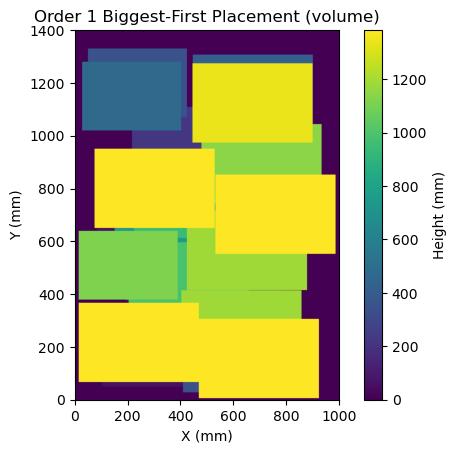

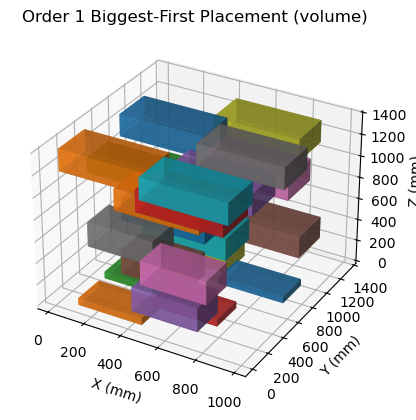

In [103]:
# boxid = 1
# x, y, z, a, v = get_box_properties_from_id(boxid)
# print(f"Sizes of box {boxid}: X = {x}, Y = {y}, Z = {z}, A = {a}, V = {v}")

# orderid = 1
# box_list = get_box_list_from_order(orderid)
# criterion = "volume"
# print(f"Box list for order {orderid}: {box_list}")
# print(f"Same list sorted by box {criterion}: {sort_order_by_size(box_list)}")

# first = Pallet()
# place_boxes_random(first, num_boxes=100, box_size_range=(100, 400))
# first.visualize_heightmap("Random")
# first.visualize_boxes("Random")

# second = Pallet()
# orderid = 1
# box_list = get_box_list_from_order(orderid)
# place_order_random(second, box_list, max_attempts=100)
# second.visualize_heightmap(f"Order {orderid} Random Placement")
# second.visualize_boxes(f"Order {orderid} Random Placement")

# plot_random_performance(100, 1000, 50)

pallet = process_order(1, algo="random", criterion="v")
print(f"Order fullfillment: {pallet.check_order_fullfillment(1)}")
pallet.visualize_heightmap(f"Order 1 Biggest-First Placement (volume)")
pallet.visualize_boxes(f"Order 1 Biggest-First Placement (volume)")

# pallet = Pallet()
# place_random_boxes(pallet, 1000, (100, 250))
# pallet.visualize_heightmap(f"Random pallet")
# pallet.visualize_boxes(f"Random pallet")
print(pallet.get_volume_utilization())
print(pallet.get_center_of_gravity_z())
print(pallet.get_area_usage_at_z(0))
print(pallet.get_packing_score())

In [104]:
scores = []
for i in range(100):
    

_IncompleteInputError: incomplete input (1230863411.py, line 3)